<a href="https://colab.research.google.com/github/manramirezpi/TransformadaFourierCanciones/blob/main/Transformada_de_fourier_de_canciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

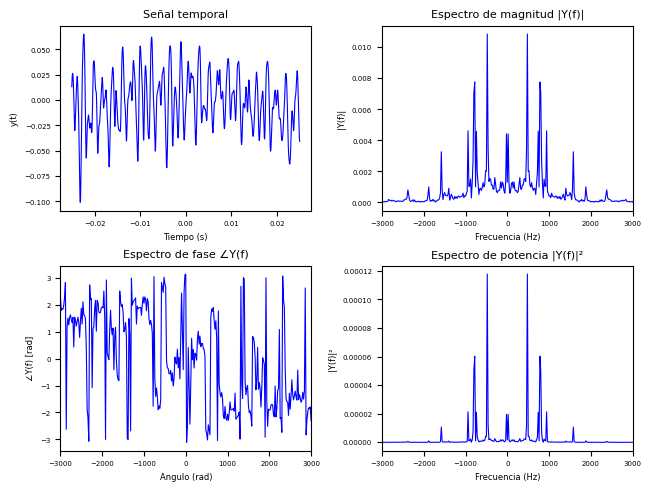

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# ── Parámetros de carga ──────────────────────────────────────────────
ruta_audio  = "Bach - Fuga en Do menor BWV 847 (Maurizio Pollini).mp3"
fm          = 44100           # frecuencia de muestreo [Hz]. Indicada por el teorema del muestreo: doble de la frecuencia maxima (20 kHz)
t_inicio    = 10.0            # inicio del fragmento [s]
duracion    = .05            # duración del fragmento [s]

# ── Carga del fragmento ──────────────────────────────────────────────

#y_audio es el vector que contiene la amplitud de la señal en cada instante t_i
y_audio, fm = librosa.load(ruta_audio,#especifica la ruta del archivo
                           sr=fm,#asigna fm como la frecuencia de muestreo
                           offset=t_inicio,#establecer el inicio
                           duration=duracion,#establecer la duracion
                           mono=True)#tratar como audio mono


N = len(y_audio)              # número de muestras. Contar el numero de muestras en el
pm = 1 / fm                   # periodo de muestreo [s]

# Vector de tiempo centrado en el origen  (análogo a su variable x)
x = np.linspace(-duracion / 2, duracion / 2, N)#Discretizacion del tiempo, en la misma cantidad de datos que y_audio

# ── Transformada de Fourier ──────────────────────────────────────────
Y      = np.fft.fft(y_audio)          # FFT compleja. Realiza la transformada de fourier discreta a cada componente.
                                      # Y retorna un vector con la misma cantidad de filas, con un nuevo valor
                                      #que en general es un numero complejo. entonces se tiene, su magnitud y su fase. Nuevo eje Y

freqs  = np.fft.fftfreq(N, d=pm)      # eje de frecuencias [Hz]. Retorna la frecuencia que consituye cada punto.
                                      #Este será el nuevo eje X (en el mundo de Fourian)

# Reordenar para que las frecuencias negativas queden a la izquierda
freqs  = np.fft.fftshift(freqs)      #reordena los valores del nuevo X para tenerlos de menor a mayor
Y      = np.fft.fftshift(Y)          #se reindexan los valores de los nuevos Y para que coincidan con su frecuencia

Y_mag  = np.abs(Y) / N               # magnitud normalizada. Se divide entre la cantidad de datos, para poder
                                     # hacer comparaciones entre muestras de diferentes tamaños
Y_fase = np.angle(Y)                 # fase [rad]. Se normaliza por la misma razon
Y_pot  = Y_mag ** 2                  # espectro de potencia.Da informacion de cuanta energia aporta cada frecuencia al total
                                     # energia proporcional al cuadrado de la amplitud

# ── Rango de frecuencias a visualizar ───────────────────────────────
f_min = -3000   # frecuencia mínima [Hz]
f_max =  3000   # frecuencia máxima [Hz]

# ── Gráfica en mosaico 2×2 ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, constrained_layout=True)
ax = axes.ravel()

etiquetas = ['Señal temporal',
             'Espectro de magnitud |Y(f)|',
             'Espectro de fase ∠Y(f)',
             'Espectro de potencia |Y(f)|²']

# Datos a graficar: (eje_x, eje_y, xlabel, ylabel, aplicar_rango_frec)
datos = [
    (x,     y_audio, 'Tiempo (s)',       'y(t)',          False),
    (freqs, Y_mag,   'Frecuencia (Hz)',  '|Y(f)|',        True),
    (freqs, Y_fase,  'Angulo (rad)',  '∠Y(f) [rad]',   True),
    (freqs, Y_pot,   'Frecuencia (Hz)',  '|Y(f)|²',       True),
]

for i, (ex, ey, xlabel, ylabel, es_frec) in enumerate(datos):
    ax[i].set_xlabel(xlabel,      fontsize=6)
    ax[i].set_ylabel(ylabel,      fontsize=6)
    ax[i].tick_params(axis='x',   labelsize=5)
    ax[i].tick_params(axis='y',   labelsize=5)
    ax[i].set_title(etiquetas[i], fontsize=8)
    if es_frec:
        ax[i].set_xlim(f_min, f_max)
    ax[i].plot(ex, ey, 'blue',    linewidth=0.8)

plt.show()

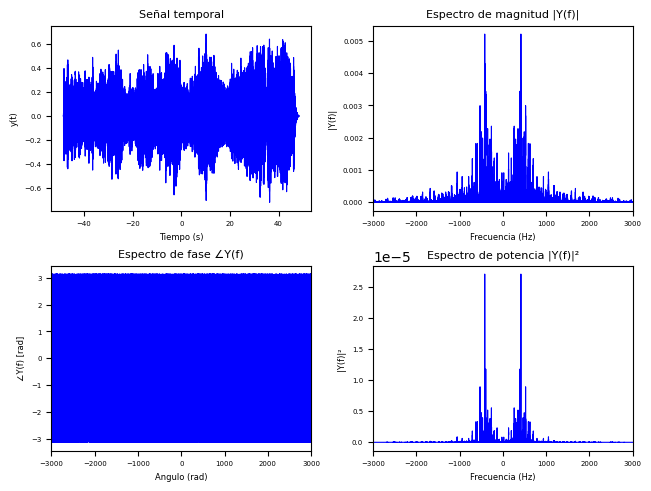

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.signal import find_peaks

# ── Parámetros de carga ──────────────────────────────────────────────
ruta_audio  = "Bach - Fuga en Do menor BWV 847 (Maurizio Pollini).mp3"
fm          = 44100           # frecuencia de muestreo [Hz]. Indicada por el teorema del muestreo: doble de la frecuencia maxima (20 kHz)
t_inicio    = 0.0            # inicio del fragmento [s]
duracion    = 97            # duración del fragmento [s]

# ── Carga del fragmento ──────────────────────────────────────────────

#y_audio es el vector que contiene la amplitud de la señal en cada instante t_i
y_audio, fm = librosa.load(ruta_audio,#especifica la ruta del archivo
                           sr=fm,#asigna fm como la frecuencia de muestreo
                           offset=t_inicio,#establecer el inicio
                           duration=duracion,#establecer la duracion
                           mono=True)#tratar como audio mono


N = len(y_audio)              # número de muestras. Contar el numero de muestras en el
pm = 1 / fm                   # periodo de muestreo [s]

# Vector de tiempo centrado en el origen  (análogo a su variable x)
x = np.linspace(-duracion / 2, duracion / 2, N)#Discretizacion del tiempo, en la misma cantidad de datos que y_audio

# ── Transformada de Fourier ──────────────────────────────────────────
Y      = np.fft.fft(y_audio)          # FFT compleja. Realiza la transformada de fourier discreta a cada componente.
                                      # Y retorna un vector con la misma cantidad de filas. Pero ahora no una, sino
                                      #2 columnas, dado que en general es un numero complejo. entonces se tiene, su
                                      #magnitud y su fase. Nuevo eje Y

freqs  = np.fft.fftfreq(N, d=pm)      # eje de frecuencias [Hz]. Retorna la frecuencia que consituye cada punto.
                                      #Este será el nuevo eje X (en el mundo de Fourian)

# Reordenar para que las frecuencias negativas queden a la izquierda
freqs  = np.fft.fftshift(freqs)      #reordena los valores del nuevo X para tenerlos de menor a mayor
Y      = np.fft.fftshift(Y)          #se reindexan los valores de los nuevos Y para que coincidan con su frecuencia

Y_mag  = np.abs(Y) / N               # magnitud normalizada. Se divide entre la cantidad de datos, para poder
                                     # hacer comparaciones entre muestras de diferentes tamaños
Y_fase = np.angle(Y)                 # fase [rad]. Se normaliza por la misma razon
Y_pot  = Y_mag ** 2                  # espectro de potencia.Da informacion de cuanta energia aporta cada frecuencia al total
                                     # energia proporcional al cuadrado de la amplitud

# ── Rango de frecuencias a visualizar ───────────────────────────────
f_min = -3000   # frecuencia mínima [Hz]
f_max =  3000   # frecuencia máxima [Hz]

# ── Gráfica en mosaico 2×2 ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, constrained_layout=True)
ax = axes.ravel()

etiquetas = ['Señal temporal',
             'Espectro de magnitud |Y(f)|',
             'Espectro de fase ∠Y(f)',
             'Espectro de potencia |Y(f)|²']

# Datos a graficar: (eje_x, eje_y, xlabel, ylabel, aplicar_rango_frec)
datos = [
    (x,     y_audio, 'Tiempo (s)',       'y(t)',          False),
    (freqs, Y_mag,   'Frecuencia (Hz)',  '|Y(f)|',        True),
    (freqs, Y_fase,  'Angulo (rad)',  '∠Y(f) [rad]',   True),
    (freqs, Y_pot,   'Frecuencia (Hz)',  '|Y(f)|²',       True),
]

for i, (ex, ey, xlabel, ylabel, es_frec) in enumerate(datos):
    ax[i].set_xlabel(xlabel,      fontsize=6)
    ax[i].set_ylabel(ylabel,      fontsize=6)
    ax[i].tick_params(axis='x',   labelsize=5)
    ax[i].tick_params(axis='y',   labelsize=5)
    ax[i].set_title(etiquetas[i], fontsize=8)
    if es_frec:
        ax[i].set_xlim(f_min, f_max)
    ax[i].plot(ex, ey, 'blue',    linewidth=0.8)

plt.show()

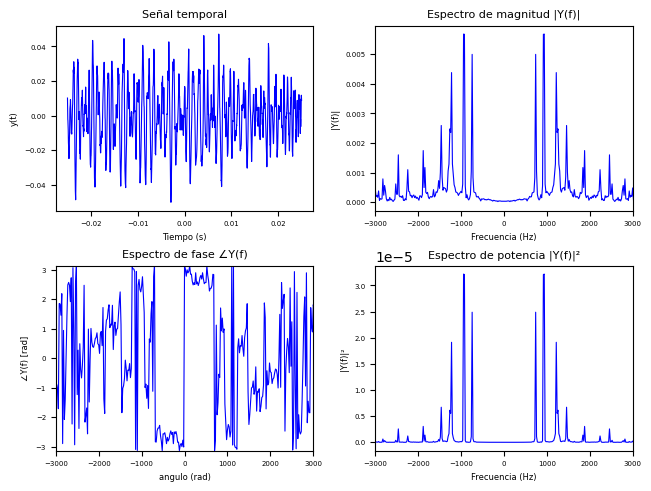

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# ── Parámetros de carga ──────────────────────────────────────────────
ruta_audio  = "Diri Diri.mp3"
fm          = 44100           # frecuencia de muestreo [Hz]. Indicada por el teorema del muestreo: doble de la frecuencia maxima (20 kHz)
t_inicio    = 10            # inicio del fragmento [s]
duracion    = 0.05            # duración del fragmento [s]

# ── Carga del fragmento ──────────────────────────────────────────────

#y_audio es el vector que contiene la amplitud de la señal en cada instante t_i
y_audio, fm = librosa.load(ruta_audio,#especifica la ruta del archivo
                           sr=fm,#asigna fm como la frecuencia de muestreo
                           offset=t_inicio,#establecer el inicio
                           duration=duracion,#establecer la duracion
                           mono=True)#tratar como audio mono


N = len(y_audio)              # número de muestras. Contar el numero de muestras en el
pm = 1 / fm                   # periodo de muestreo [s]

# Vector de tiempo centrado en el origen  (análogo a su variable x)
x = np.linspace(-duracion / 2, duracion / 2, N)#Discretizacion del tiempo, en la misma cantidad de datos que y_audio

# ── Transformada de Fourier ──────────────────────────────────────────
Y      = np.fft.fft(y_audio)          # FFT compleja. Realiza la transformada de fourier discreta a cada componente.
                                      # Y retorna un vector con la misma cantidad de filas. Pero ahora no una, sino
                                      #2 columnas, dado que en general es un numero complejo. entonces se tiene, su
                                      #magnitud y su fase. Nuevo eje Y

freqs  = np.fft.fftfreq(N, d=pm)      # eje de frecuencias [Hz]. Retorna la frecuencia que consituye cada punto.
                                      #Este será el nuevo eje X (en el mundo de Fourian)

# Reordenar para que las frecuencias negativas queden a la izquierda
freqs  = np.fft.fftshift(freqs)      #reordena los valores del nuevo X para tenerlos de menor a mayor
Y      = np.fft.fftshift(Y)          #se reindexan los valores de los nuevos Y para que coincidan con su frecuencia

Y_mag  = np.abs(Y) / N               # magnitud normalizada. Se divide entre la cantidad de datos, para poder
                                     # hacer comparaciones entre muestras de diferentes tamaños
Y_fase = np.angle(Y)                 # fase [rad]. Se normaliza por la misma razon
Y_pot  = Y_mag ** 2                  # espectro de potencia.Da informacion de cuanta energia aporta cada frecuencia al total
                                     # energia proporcional al cuadrado de la amplitud

# ── Rango de frecuencias a visualizar ───────────────────────────────
f_min = -3000   # frecuencia mínima [Hz]
f_max =  3000   # frecuencia máxima [Hz]

# ── Gráfica en mosaico 2×2 ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, constrained_layout=True)
ax = axes.ravel()

etiquetas = ['Señal temporal',
             'Espectro de magnitud |Y(f)|',
             'Espectro de fase ∠Y(f)',
             'Espectro de potencia |Y(f)|²']

# Datos a graficar: (eje_x, eje_y, xlabel, ylabel, aplicar_rango_frec)
datos = [
    (x,     y_audio, 'Tiempo (s)',       'y(t)',          False),
    (freqs, Y_mag,   'Frecuencia (Hz)',  '|Y(f)|',        True),
    (freqs, Y_fase,  'angulo (rad)',  '∠Y(f) [rad]',   True),
    (freqs, Y_pot,   'Frecuencia (Hz)',  '|Y(f)|²',       True),
]

for i, (ex, ey, xlabel, ylabel, es_frec) in enumerate(datos):
    ax[i].set_xlabel(xlabel,      fontsize=6)
    ax[i].set_ylabel(ylabel,      fontsize=6)
    ax[i].tick_params(axis='x',   labelsize=5)
    ax[i].tick_params(axis='y',   labelsize=5)
    ax[i].set_title(etiquetas[i], fontsize=8)
    if es_frec:
        ax[i].set_xlim(f_min, f_max)
    if ylabel == '∠Y(f) [rad]':
        ax[i].set_ylim(-np.pi, np.pi)
    ax[i].plot(ex, ey, 'blue',    linewidth=0.8)

plt.show()

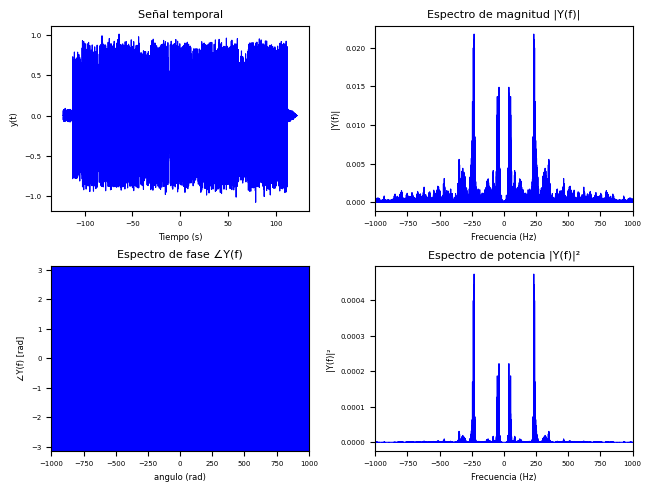

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# ── Parámetros de carga ──────────────────────────────────────────────
ruta_audio  = "Diri Diri.mp3"
fm          = 44100           # frecuencia de muestreo [Hz]. Indicada por el teorema del muestreo: doble de la frecuencia maxima (20 kHz)
t_inicio    = 0            # inicio del fragmento [s]
duracion    = 245            # duración del fragmento [s]

# ── Carga del fragmento ──────────────────────────────────────────────

#y_audio es el vector que contiene la amplitud de la señal en cada instante t_i
y_audio, fm = librosa.load(ruta_audio,#especifica la ruta del archivo
                           sr=fm,#asigna fm como la frecuencia de muestreo
                           offset=t_inicio,#establecer el inicio
                           duration=duracion,#establecer la duracion
                           mono=True)#tratar como audio mono


N = len(y_audio)              # número de muestras. Contar el numero de muestras en el
pm = 1 / fm                   # periodo de muestreo [s]

# Vector de tiempo centrado en el origen  (análogo a su variable x)
x = np.linspace(-duracion / 2, duracion / 2, N)#Discretizacion del tiempo, en la misma cantidad de datos que y_audio

# ── Transformada de Fourier ──────────────────────────────────────────
Y      = np.fft.fft(y_audio)          # FFT compleja. Realiza la transformada de fourier discreta a cada componente.
                                      # Y retorna un vector con la misma cantidad de filas. Pero ahora no una, sino
                                      #2 columnas, dado que en general es un numero complejo. entonces se tiene, su
                                      #magnitud y su fase. Nuevo eje Y

freqs  = np.fft.fftfreq(N, d=pm)      # eje de frecuencias [Hz]. Retorna la frecuencia que consituye cada punto.
                                      #Este será el nuevo eje X (en el mundo de Fourian)

# Reordenar para que las frecuencias negativas queden a la izquierda
freqs  = np.fft.fftshift(freqs)      #reordena los valores del nuevo X para tenerlos de menor a mayor
Y      = np.fft.fftshift(Y)          #se reindexan los valores de los nuevos Y para que coincidan con su frecuencia

Y_mag  = np.abs(Y) / N               # magnitud normalizada. Se divide entre la cantidad de datos, para poder
                                     # hacer comparaciones entre muestras de diferentes tamaños
Y_fase = np.angle(Y)                 # fase [rad]. Se normaliza por la misma razon
Y_pot  = Y_mag ** 2                  # espectro de potencia.Da informacion de cuanta energia aporta cada frecuencia al total
                                     # energia proporcional al cuadrado de la amplitud

# ── Rango de frecuencias a visualizar ───────────────────────────────
f_min = -1000   # frecuencia mínima [Hz]
f_max =  1000   # frecuencia máxima [Hz]

# ── Gráfica en mosaico 2×2 ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, constrained_layout=True)
ax = axes.ravel()

etiquetas = ['Señal temporal',
             'Espectro de magnitud |Y(f)|',
             'Espectro de fase ∠Y(f)',
             'Espectro de potencia |Y(f)|²']

# Datos a graficar: (eje_x, eje_y, xlabel, ylabel, aplicar_rango_frec)
datos = [
    (x,     y_audio, 'Tiempo (s)',       'y(t)',          False),
    (freqs, Y_mag,   'Frecuencia (Hz)',  '|Y(f)|',        True),
    (freqs, Y_fase,  'angulo (rad)',  '∠Y(f) [rad]',   True),
    (freqs, Y_pot,   'Frecuencia (Hz)',  '|Y(f)|²',       True),
]

for i, (ex, ey, xlabel, ylabel, es_frec) in enumerate(datos):
    ax[i].set_xlabel(xlabel,      fontsize=6)
    ax[i].set_ylabel(ylabel,      fontsize=6)
    ax[i].tick_params(axis='x',   labelsize=5)
    ax[i].tick_params(axis='y',   labelsize=5)
    ax[i].set_title(etiquetas[i], fontsize=8)
    if es_frec:
        ax[i].set_xlim(f_min, f_max)       # rango definido arriba en f_min, f_max
    if ylabel == '∠Y(f) [rad]':
        ax[i].set_ylim(-np.pi, np.pi)      # la fase definida entre -π y  π
    ax[i].plot(ex, ey, 'blue',    linewidth=0.8)

plt.show()

0.05 s de Bach:

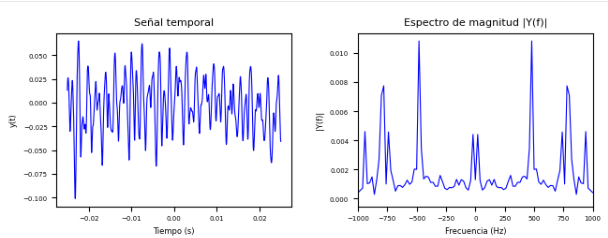


0.05 s de ñengo:


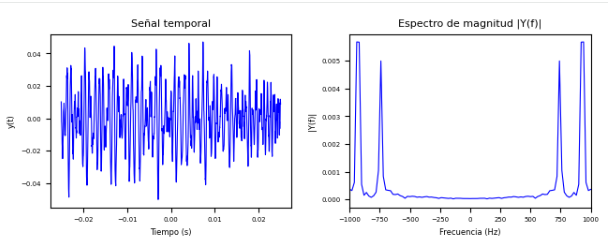

Canción completa de Bach:

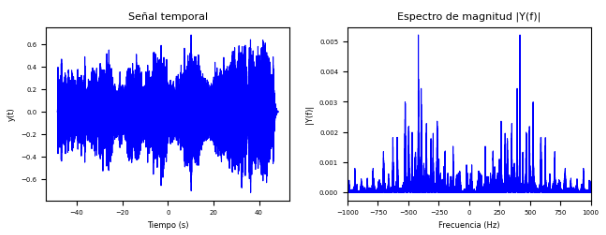



Canción completa de Ñengo:

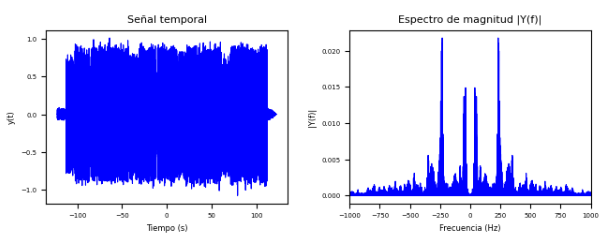